# Test: JAX-Native WGAN for Tabular Data

Quick smoke test of `wgan_jax.py` with a synthetic DGP.

In [1]:
import numpy as np
import pandas as pd
from wgan_jax import WGAN, compare_dfs

## 1. Synthetic Dataset

DGP: 1 covariate V1, binary treatment W, outcome Y with ATT = 2.0, binary covariate `married`.

In [18]:
np.random.seed(42)
N = 2000

V1 = np.random.lognormal(0, 1, N)
# add normal mixture as V2
V2 = np.concatenate([np.random.normal(0, 1, N//2), np.random.normal(5, 1, N//2)])
W = np.random.binomial(1, 0.5, N).astype(float)
married = np.random.choice([0.0, 1.0], N)
Y = 3 + 1.5 * V1 + 2 * W + 0.5 * married + np.random.normal(0, 0.5, N)

df = pd.DataFrame({"Y": Y, "V1": V1, "married": married, "W": W, "V2": V2})
df.describe()

,Y,V1,married,W,V2
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,6.778000,1.716612,0.469500,0.486000,2.493557
std,3.599019,2.304500,0.499194,0.499929,2.683738
min,2.014536,0.039114,0.000000,0.000000,-3.019512
25%,4.836824,0.536514,0.000000,0.000000,-0.000022
50%,6.070103,1.045706,0.000000,0.000000,2.511932
75%,7.582704,1.979767,1.000000,1.000000,4.999935
max,74.826831,47.121600,1.000000,1.000000,8.243093


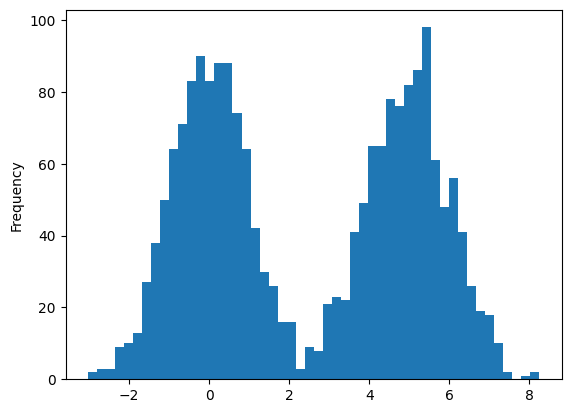

In [20]:
df.V2.plot(kind="hist", bins=50)
plt.show()

## 2. Initialize and Train

In [21]:
wgan = WGAN(
    df=df,
    continuous_vars=["Y", "V1", "V2"],
    categorical_vars=["married"],
    conditioning_vars=["W"],
)

WGAN initialized: d_x=5 (cont=3, cat=2), d_cond=1, noise_dim=5


In [22]:
history = wgan.train(max_epochs=300, batch_size=256, print_every=25)

epoch     0 | WD_train   0.6688 | WD_test   1.0660 | 2s
epoch    25 | WD_train   0.4679 | WD_test   0.3762 | 7s
epoch    50 | WD_train   0.2366 | WD_test   0.3529 | 7s
epoch    75 | WD_train   0.2198 | WD_test   0.1754 | 7s
epoch   100 | WD_train   0.1550 | WD_test   0.1657 | 7s
epoch   125 | WD_train   0.2009 | WD_test   0.2171 | 7s
epoch   150 | WD_train   0.1958 | WD_test   0.2270 | 7s
epoch   175 | WD_train   0.1308 | WD_test   0.0685 | 7s
epoch   200 | WD_train   0.1762 | WD_test   0.2681 | 7s
epoch   225 | WD_train   0.1454 | WD_test   0.1684 | 7s
epoch   250 | WD_train   0.1476 | WD_test   0.1729 | 7s
epoch   275 | WD_train   0.1080 | WD_test   0.1469 | 7s


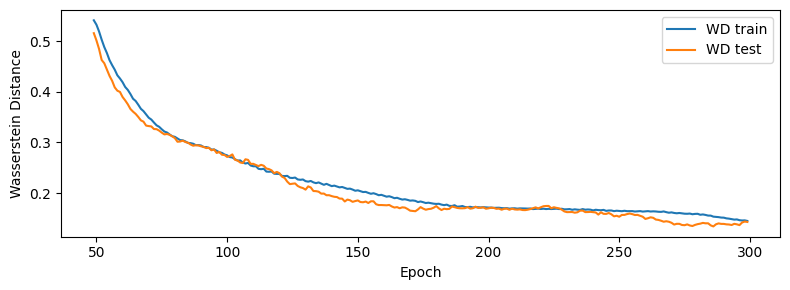

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 3))
plt.plot(pd.Series(history["wd_train"]).rolling(50).mean(), label="WD train")
plt.plot(pd.Series(history["wd_test"])
.rolling(50).mean(), label="WD test")
plt.xlabel("Epoch")
plt.ylabel("Wasserstein Distance")
plt.legend()
plt.tight_layout()
plt.show()

## 3. Generate and Compare

In [24]:
# Generate conditioned on observed W values
df_gen = wgan.generate(df[["W"]], seed=0)
df_gen.describe()

,Y,V1,V2,married,W
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,7.110068,1.782686,2.646958,0.460000,0.486000
std,3.222121,2.072846,2.632171,0.498522,0.499929
min,1.586903,-0.630488,-5.558663,0.000000,0.000000
25%,5.133060,0.667142,0.170548,0.000000,0.000000
50%,6.423500,1.119589,2.701015,0.000000,0.000000
75%,7.900313,1.998594,5.144740,1.000000,1.000000
max,33.527184,20.064793,9.370266,1.000000,1.000000


------------- comparison of means -------------
W         0.0         1.0      
source   fake  real  fake  real
V1       1.90  1.82  1.66  1.60
married  0.47  0.49  0.45  0.45
V2       2.69  2.50  2.60  2.49
Y        6.37  5.99  7.90  7.61

------------- comparison of stds  -------------
W         0.0         1.0      
source   fake  real  fake  real
V1       2.31  2.65  1.78  1.86
married  0.50  0.50  0.50  0.50
V2       2.58  2.68  2.68  2.69
Y        3.50  4.04  2.68  2.84



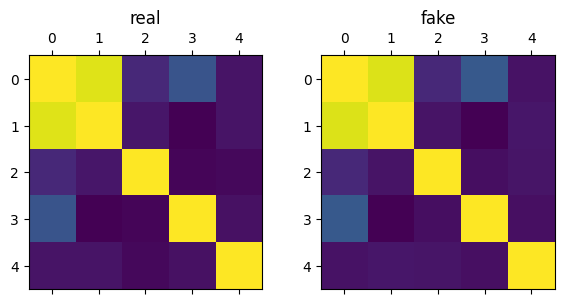

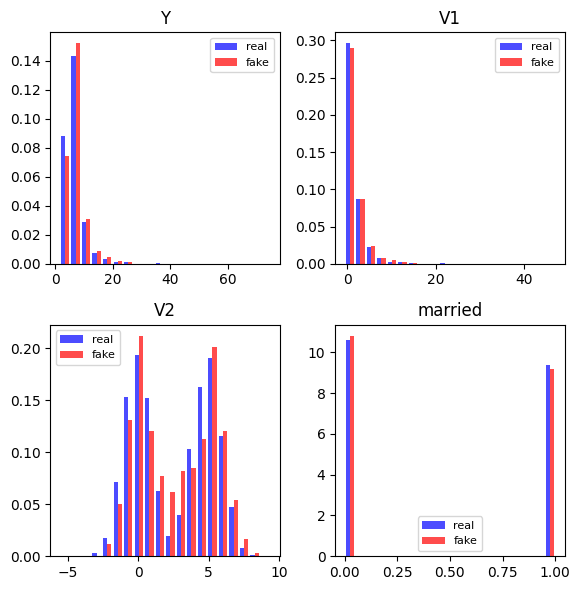

In [25]:
compare_dfs(
    df, df_gen,
    histogram=dict(variables=["Y", "V1", "V2","married"], nrow=2, ncol=2),
    table_groupby=["W"],
)

## 4. Save / Load Round-Trip

In [ ]:
wgan.save("/tmp/wgan_test_checkpoint")

wgan2 = WGAN.load("/tmp/wgan_test_checkpoint", df=df)
df_gen2 = wgan2.generate(df[["W"]], seed=0)

# Should produce identical output
print("Max diff:", (df_gen[["Y", "V1"]].values - df_gen2[["Y", "V1"]].values).max())